In [1]:
# Importação de bibliotecas importantes
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from sklearn.preprocessing import ()

/home/user/Desktop/ml-ds/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")
df = pd.read_csv(os.path.join(path, "adult.csv"))

---
## ANÁLISE EXPLORATÓRIA DE DADOS

Primeiro, vamos realizar uma análise exploratória estrutural para entender um pouco do dataset.

In [3]:
print("\n" + "="*60)
print("\t\t     INFORMAÇÕES GERAIS")
print("="*60)

print(f"Formato: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"\nTipos de dados:\n{df.dtypes}")


		     INFORMAÇÕES GERAIS
Formato: 48842 linhas e 15 colunas

Tipos de dados:
age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object


In [4]:
print(f"Exibindo as 5 linhas aletoriamente do conjunto de dados:")
df.sample(5, random_state=42)

Exibindo as 5 linhas aletoriamente do conjunto de dados:


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
7762,56,Private,33115,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
23881,25,Private,112847,HS-grad,9,Married-civ-spouse,Transport-moving,Own-child,Other,Male,0,0,40,United-States,<=50K
30507,43,Private,170525,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,14344,0,40,United-States,>50K
28911,32,Private,186788,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
19484,39,Private,277886,Bachelors,13,Married-civ-spouse,Sales,Wife,White,Female,0,0,30,United-States,<=50K


In [5]:
print("\n" + "="*60)
print("\t\t  INFORMAÇÕES DETALHADAS")
print("="*60)

df.info()


		  INFORMAÇÕES DETALHADAS
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


Como existem 48842 registros no total, valor que também corresponde aos registros de cada feature, percebemos que não existem missing values a serem tratados até o momento. Podemos confirmar isso da seguinte forma:

In [6]:
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

Isso, entretanto, não significa que não existe de maneira definitiva missing values. Eles podem estar representados no dataset por outras formas. Podemos analisar isso por meio dos valores únicos em cada coluna.

Verificando os valores únicos por coluna, temos:

In [7]:
print("Valores únicos por coluna:")
df.nunique()

Valores únicos por coluna:


age                   74
workclass              9
fnlwgt             28523
education             16
educational-num       16
marital-status         7
occupation            15
relationship           6
race                   5
gender                 2
capital-gain         123
capital-loss          99
hours-per-week        96
native-country        42
income                 2
dtype: int64

Podemos ver quais são os valores únicos da seguinte forma

In [8]:
for col in df.columns:
    if df[col].nunique() <= 15:
        print(f"Valores únicos da coluna {col}:")
        for val in df[col].unique():
            print(val, end=", ")
        print("\n")

Valores únicos da coluna workclass:
Private, Local-gov, ?, Self-emp-not-inc, Federal-gov, State-gov, Self-emp-inc, Without-pay, Never-worked, 

Valores únicos da coluna marital-status:
Never-married, Married-civ-spouse, Widowed, Divorced, Separated, Married-spouse-absent, Married-AF-spouse, 

Valores únicos da coluna occupation:
Machine-op-inspct, Farming-fishing, Protective-serv, ?, Other-service, Prof-specialty, Craft-repair, Adm-clerical, Exec-managerial, Tech-support, Sales, Priv-house-serv, Transport-moving, Handlers-cleaners, Armed-Forces, 

Valores únicos da coluna relationship:
Own-child, Husband, Not-in-family, Unmarried, Wife, Other-relative, 

Valores únicos da coluna race:
Black, White, Asian-Pac-Islander, Other, Amer-Indian-Eskimo, 

Valores únicos da coluna gender:
Male, Female, 

Valores únicos da coluna income:
<=50K, >50K, 



Isso nos permite uma melhor visualização dos valores que estão sendo representados no conjunto de dados e perceber que existem missing values em colunas como `workclass` e `occupation`, que possuem ? como resposta faltante.

Mostrando as estatísticas descritivas das variáveis numéricas:

In [9]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### Análise exploratória univariada

In [10]:
numeric_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(include=[str]).columns.tolist()

In [11]:
print("Variáveis numéricas:", numeric_vars)
print("Variáveis categóricas:", categorical_vars)

Variáveis numéricas: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Variáveis categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


In [12]:
for var in numeric_vars:
    print(f"\n{var.upper()}")
    data = df[var]

    # Medidas
    print(f"\tMédia: {data.mean():.2f}")
    print(f"\tMediana: {data.median():.2f}")
    print(f"\tStd: {data.std():.2f}")

    # Outliers
    Q1 = data.quantile(q=0.25)
    Q3 = data.quantile(q=0.75)
    IQR = Q3 - Q1

    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    print(f"\tOutliers: {len(outliers)} ({len(outliers)/len(data) * 100:.1f}%)")


AGE
	Média: 38.64
	Mediana: 37.00
	Std: 13.71
	Outliers: 216 (0.4%)

FNLWGT
	Média: 189664.13
	Mediana: 178144.50
	Std: 105604.03
	Outliers: 1453 (3.0%)

EDUCATIONAL-NUM
	Média: 10.08
	Mediana: 10.00
	Std: 2.57
	Outliers: 1794 (3.7%)

CAPITAL-GAIN
	Média: 1079.07
	Mediana: 0.00
	Std: 7452.02
	Outliers: 4035 (8.3%)

CAPITAL-LOSS
	Média: 87.50
	Mediana: 0.00
	Std: 403.00
	Outliers: 2282 (4.7%)

HOURS-PER-WEEK
	Média: 40.42
	Mediana: 40.00
	Std: 12.39
	Outliers: 13496 (27.6%)


Fazendo uma representação gráfica para representar melhor a densidade/frequência de valores e outliers:

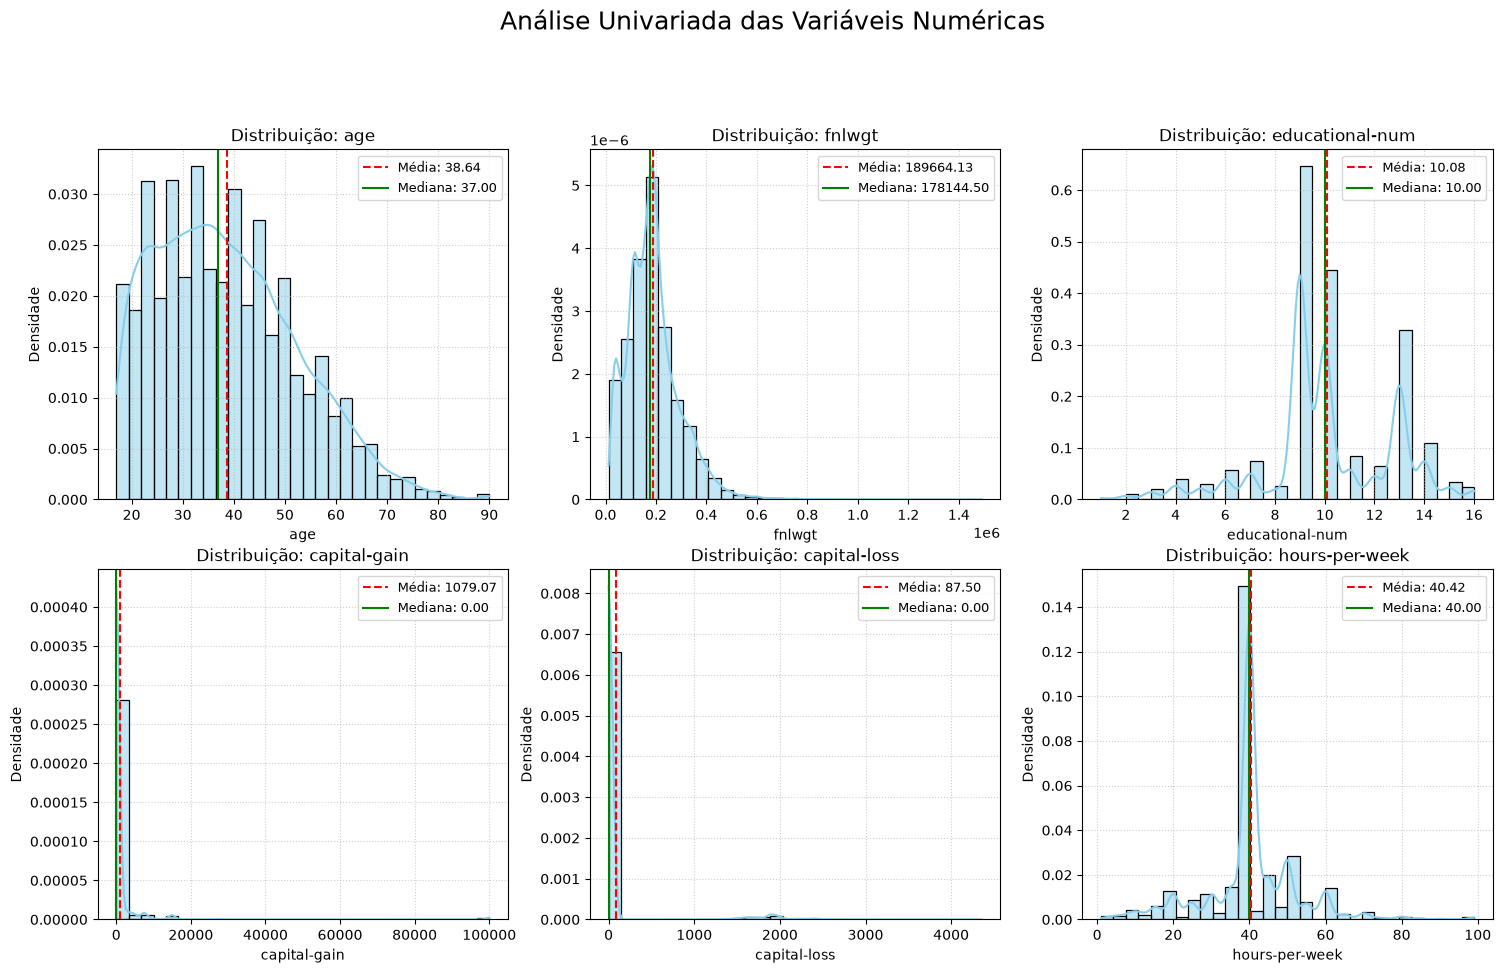

In [13]:
# Visualização em histogramas
n_vars = len(numeric_vars)
cols = 3
rows = int(np.ceil(n_vars / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
fig.suptitle("Análise Univariada das Variáveis Numéricas", fontsize=18, y=1.02)

axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=var,
        kde=True,
        bins=30,
        ax=ax,
        color='skyblue',
        edgecolor='black',
        stat='density'
    )
    
    ax.axvline(df[var].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Média: {df[var].mean():.2f}')
    ax.axvline(df[var].median(), color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {df[var].median():.2f}')

    ax.set_title(f'Distribuição: {var}', fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Densidade', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

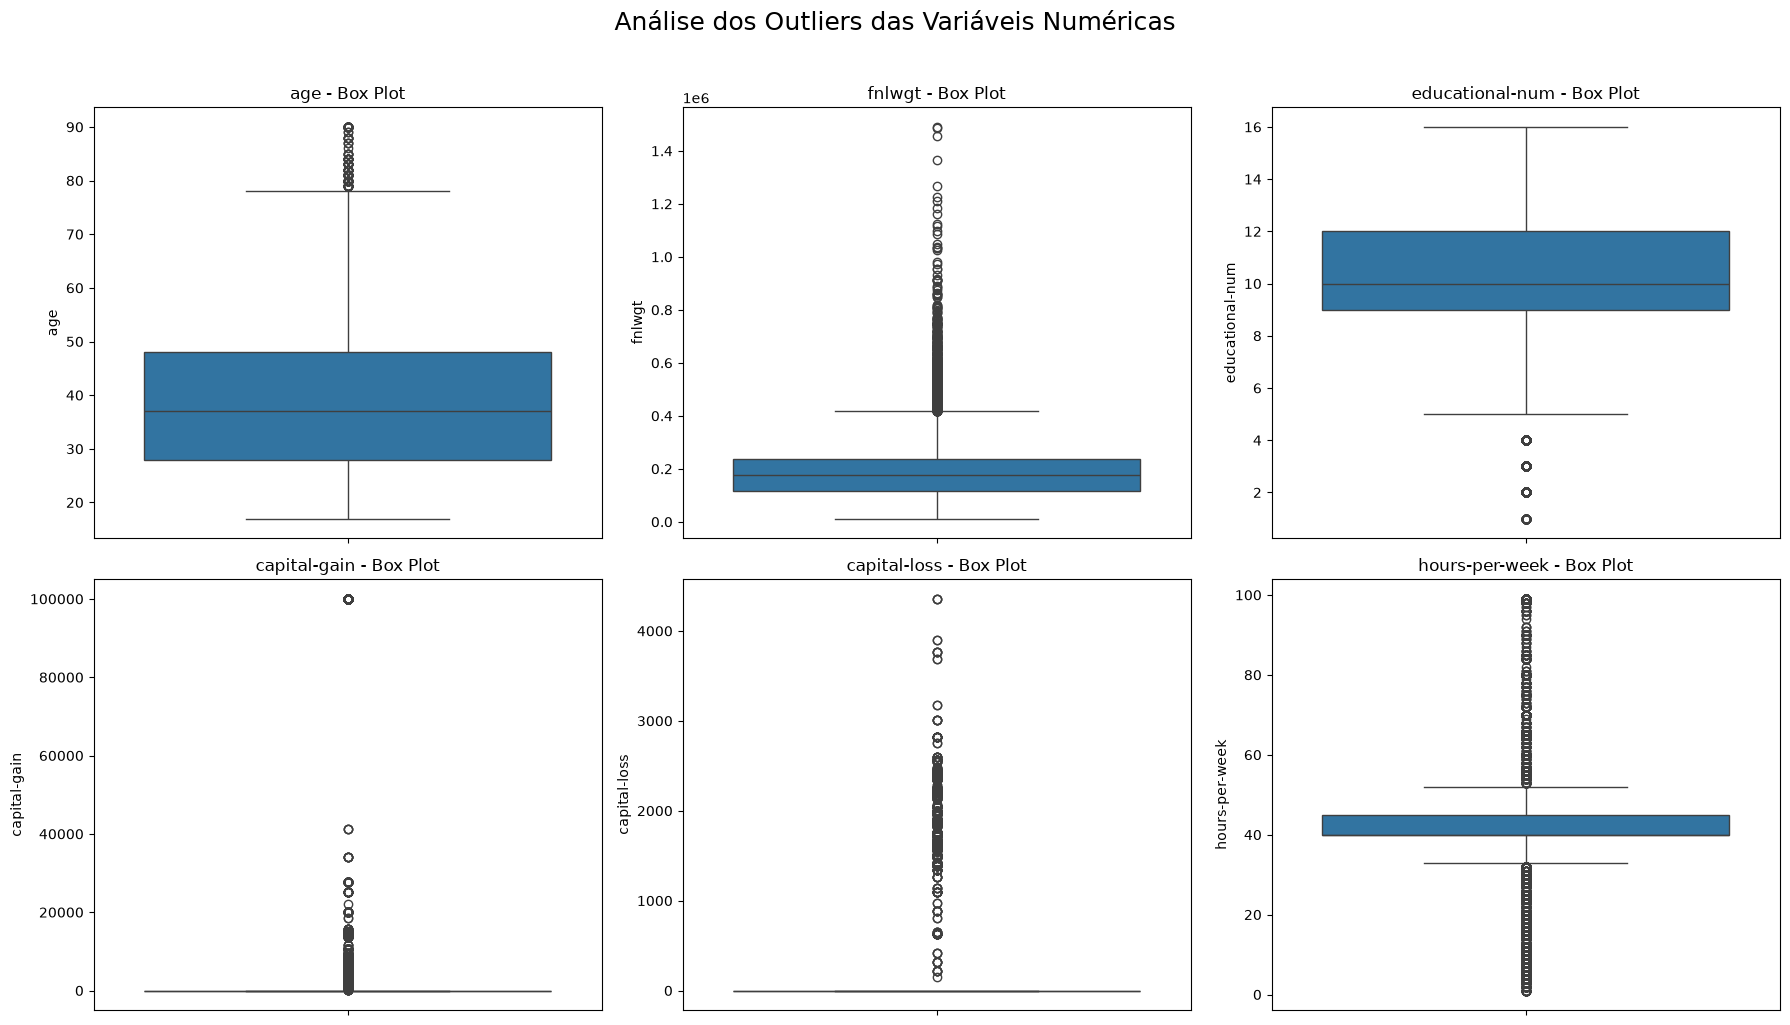

In [14]:
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
fig.suptitle("Análise dos Outliers das Variáveis Numéricas", fontsize=18, y=1.02)

axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[var])

    plt.title(f'{var} - Box Plot')
    
plt.tight_layout()
plt.show()

Fazendo uma análise já visual das variáveis categóricas, temos o seguinte:

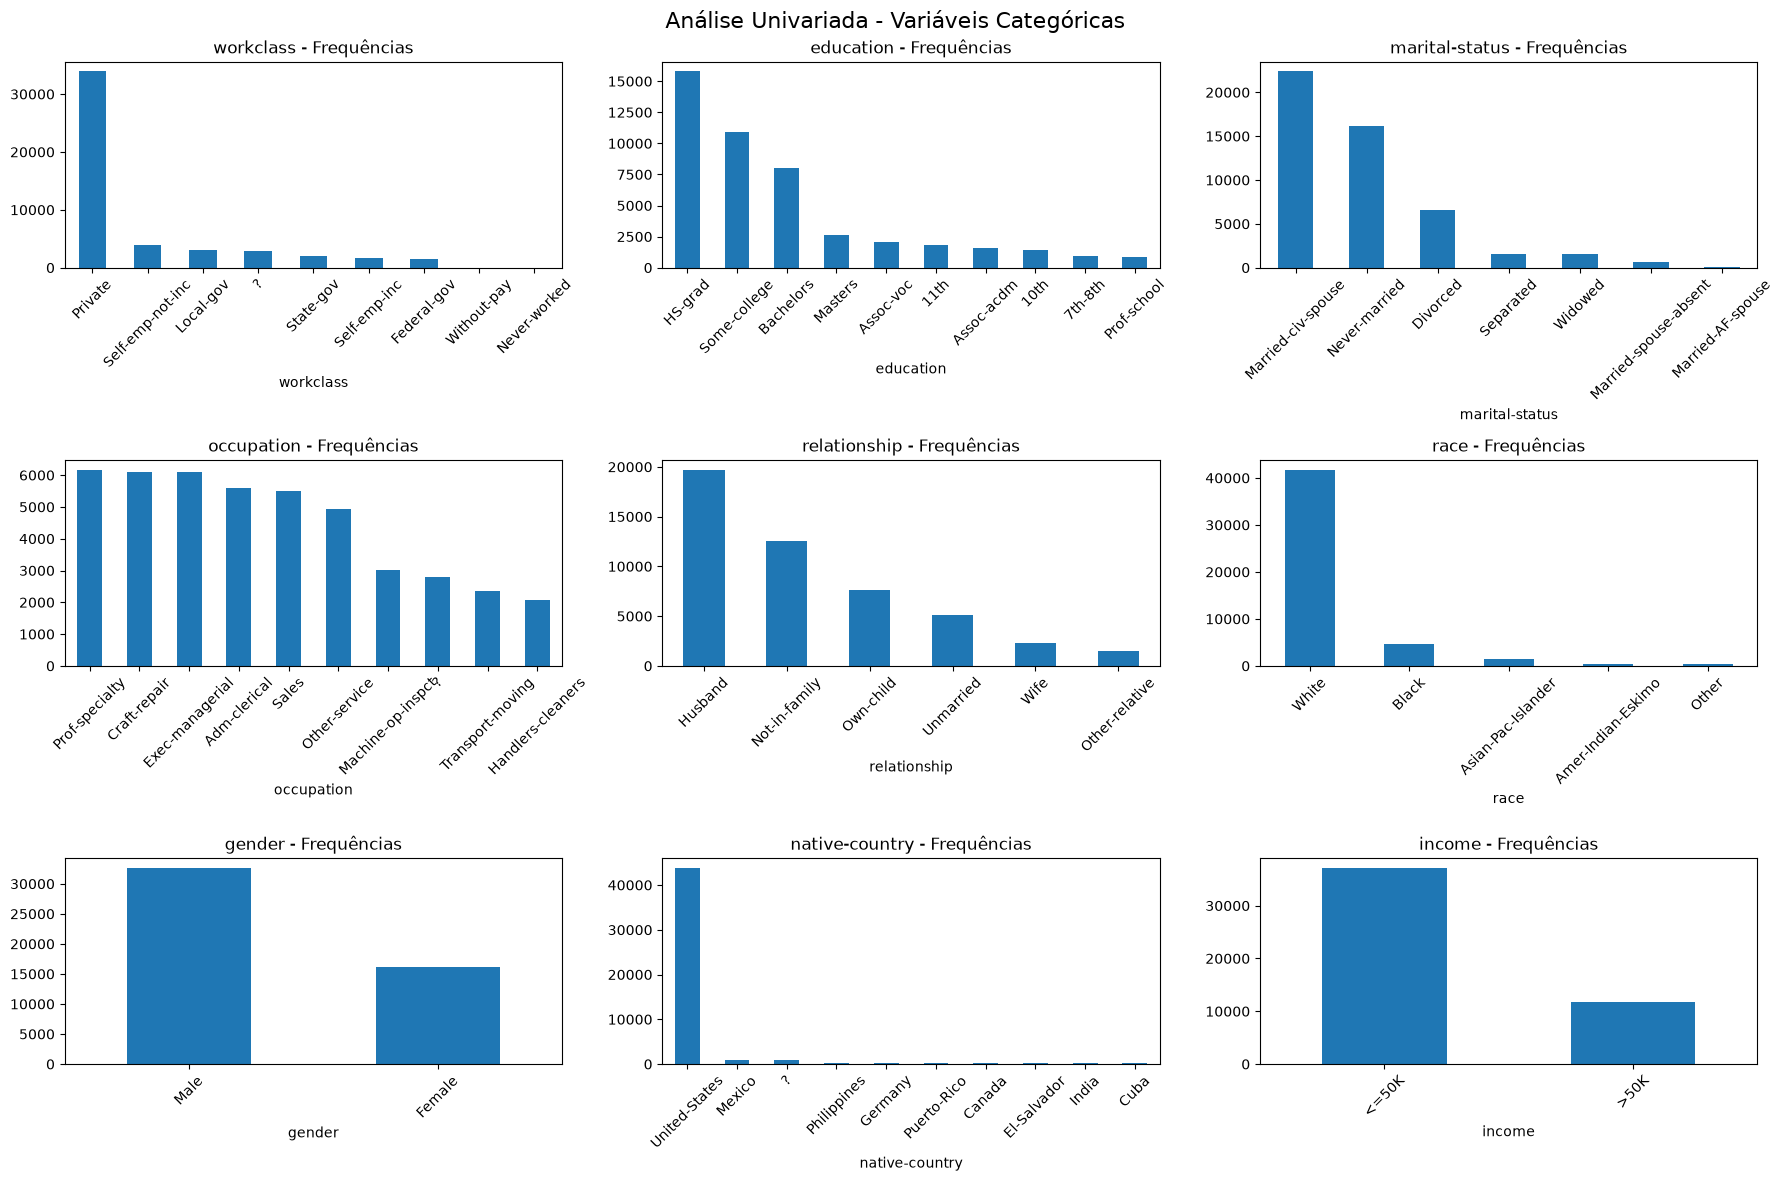

In [15]:
# Visualizações das variáveis categóricas
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Análise Univariada - Variáveis Categóricas', fontsize=16)
for i, var in enumerate(categorical_vars):
    if var in df.columns:
        row = i // 3
        col = i % 3

        # Contagem de valores
        value_counts = df[var].value_counts().head(10)

        if len(value_counts) <= 10:  # Bar plot para poucas categorias
            value_counts.plot(kind='bar', ax=axes[row, col])
        else:  # Horizontal bar plot para muitas categorias
            value_counts.plot(kind='barh', ax=axes[row, col])

        axes[row, col].set_title(f'{var} - Frequências')
        axes[row, col].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Análise Exploratória Bi/Multivariada

A variável alvo `income` não está codificada de uma forma que o modelo de classificação consiga entender. Para isso, antes mesmo da etapa de pré-processamento faremos uma transformação dessa variável para que possamos realizar análises de correlação entre as features e o target nessa etapa.

In [16]:
df['above_50k'] = df['income'].apply(lambda x: 0 if x == '<=50K' else 1)
df.drop(columns='income', inplace=True)

target_var = 'above_50k'

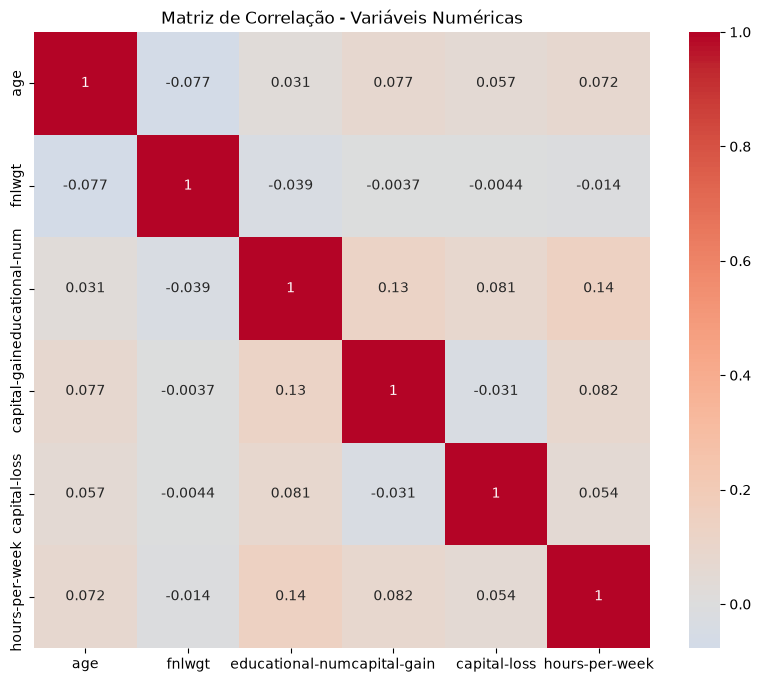

In [17]:
correlation_matrix = df[numeric_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlação - Variáveis Numéricas')

plt.show()

In [18]:
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            strong_corr.append({
                'var1': correlation_matrix.columns[i],
                'var2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

if strong_corr:
    print("\n🔥 CORRELAÇÕES FORTES (|r| > 0.5):")
    for corr in strong_corr:
        print(f"  {corr['var1']} ↔ {corr['var2']}: {corr['correlation']:.3f}")
else:
    print("\nNão existem correlações fortes entre as colunas numéricas para esse conjunto de dados")


Não existem correlações fortes entre as colunas numéricas para esse conjunto de dados


Analisando as correlações entre a variável alvo e as variáveis numéricas:

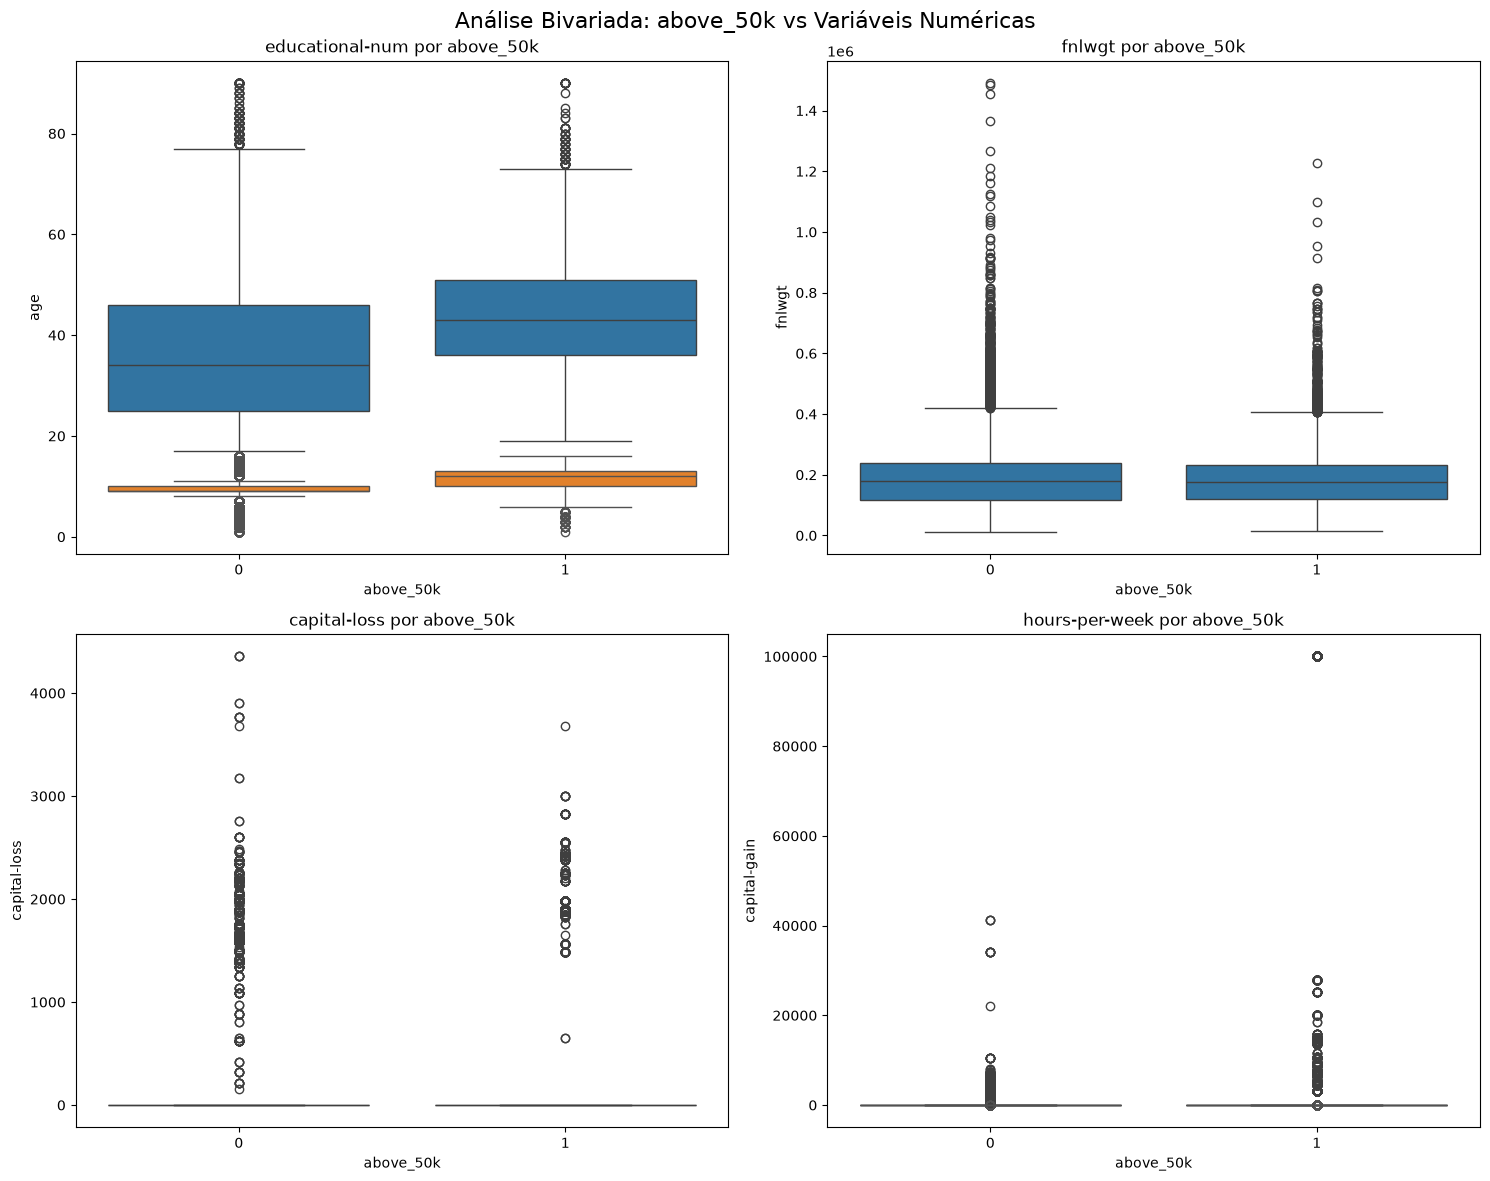

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Análise Bivariada: {target_var} vs Variáveis Numéricas', fontsize=16)
numeric_for_analysis = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

for i, var in enumerate(numeric_for_analysis):
    row = i // 3
    col = i % 2

    # Box plot por categoria do target
    sns.boxplot(data=df, x=target_var, y=var, ax=axes[row, col])
    axes[row, col].set_title(f'{var} por {target_var}')

plt.tight_layout()
plt.show()

---

## 🧹 PRÉ-PROCESSAMENTO DE DADOS

### Tratamento de missing values

Como visto, apesar de não haverem valores faltantes propriamente ditos nas colunas, temos valores faltantes representados por outros símbolos. Isso ocorre nas colunas `workclass` e `occupation`.

In [20]:
df['workclass'] = df['workclass'].replace('?', 'Unknown')
df['occupation'] = df['workclass'].replace('?', 'Unknown')

### Tratamento de outliers

Temos uma grande quantidade de valores outliers nas variáveis numéricas:

| Variável | Outliers (abs) | Outliers (%) |
|---|---|---|
|AGE|216|0.4|
|FNLWGT|1453|3.0%|
|EDUCATIONAL-NUM|1794|3.7%|
|CAPITAL-GAIN|4035|8.3%|
|CAPITAL-LOSS|2282|4.7%|
|HOURS-PER-WEEK|13496|27.6%|

Vamos tratá-los conforme cada variável exige:

In [21]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [22]:
# Análise de outliers em Age
print("\n🔍 Outliers em Age:")
age_outliers, age_lower, age_upper = detect_outliers_iqr(df, 'age')
print(f"Outliers encontrados: {len(age_outliers)}")
print(f"Limites: {age_lower:.1f} - {age_upper:.1f}")
print("Valores extremos:", age_outliers['age'].sort_values().tolist())


🔍 Outliers em Age:
Outliers encontrados: 216
Limites: -2.0 - 78.0
Valores extremos: [79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 82, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 83, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 85, 85, 85, 85, 85, 86, 87, 87, 87, 88, 88, 88, 88, 88, 88, 89, 89, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90, 90]


Como todos os outliers para idade podem ser legítimos, então mantemos.

Análise exploratória pode ser melhor explorada, mas paremos por aqui.